# CCS cement retrofit NPV simulation

Run the CCS cement retrofit Monte Carlo simulation and visualize the resulting NPV distribution.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from cement.cement_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_RETROFIT_BAU_MODE,
    DEFAULT_SAMPLE_SIZE,
    simulate_cement_results,
)


In [2]:
TECHNOLOGY = 'ccs'
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED
RETROFIT_BAU_MODE = DEFAULT_RETROFIT_BAU_MODE

results_by_technology = simulate_cement_results(
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    technologies=(TECHNOLOGY,),
    retrofit_bau_mode=RETROFIT_BAU_MODE,
)
simulation = results_by_technology[TECHNOLOGY]
results = pd.DataFrame(simulation)
results.head()


,run_id,technology,technology_type,retrofit_bau_mode,annual_output_t,capex_eur_per_t,fixed_opex_eur_per_t,variable_opex_eur_per_t,fuel_consumption_mwh_th_per_t,electricity_consumption_mwh_per_t,...,bau_variable_opex_eur_per_t,bau_fuel_consumption_mwh_th_per_t,bau_electricity_consumption_mwh_per_t,bau_emissions_tco2_per_t,capex_change_eur_per_t,fixed_opex_change_eur_per_t,variable_opex_change_eur_per_t,fuel_consumption_reduction_fraction,electricity_consumption_reduction_fraction,emissions_reduction_fraction
0,0,ccs,retrofit,sampled,1000000.0,235.083574,19.497860,6.041350,-0.042077,0.288751,...,5.135369,0.657332,0.084504,0.620035,69.604453,4.559950,0.905981,1.064011,-2.417009,0.883560
1,1,ccs,retrofit,sampled,1000000.0,233.181520,24.542336,6.364786,-0.120399,0.285092,...,5.125930,0.649577,0.093378,0.602551,74.403952,9.595418,1.238855,1.185350,-2.053082,0.908145
2,2,ccs,retrofit,sampled,1000000.0,225.607776,23.383198,6.325317,-0.096528,0.294696,...,5.431670,0.697878,0.085678,0.683904,58.435817,8.918948,0.893646,1.138317,-2.439580,0.909357
3,3,ccs,retrofit,sampled,1000000.0,317.069295,20.005661,8.005823,0.061388,0.043332,...,5.260010,0.693428,0.089539,0.634547,153.121934,6.003933,2.745813,0.911472,0.516059,0.907840
4,4,ccs,retrofit,sampled,1000000.0,261.557296,23.602637,6.342357,0.675121,0.090141,...,5.371749,0.694798,0.084480,0.652753,109.673749,8.882959,0.970608,0.028321,-0.067006,0.890468


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
npv_eur_per_t = results["npv_eur_per_t"]

summary = pd.concat(
    [
        npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR"
        ),
        npv_eur_per_t.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV EUR/t"
        ),
    ],
    axis=1,
)
summary


,NPV million EUR,NPV EUR/t
count,100000.000000,100000.000000
mean,611.818676,24.472747
std,187.072467,7.482899
min,-50.122575,-2.004903
5%,284.648223,11.385929
50%,625.901284,25.036051
95%,887.537648,35.501506
max,1056.226737,42.249069


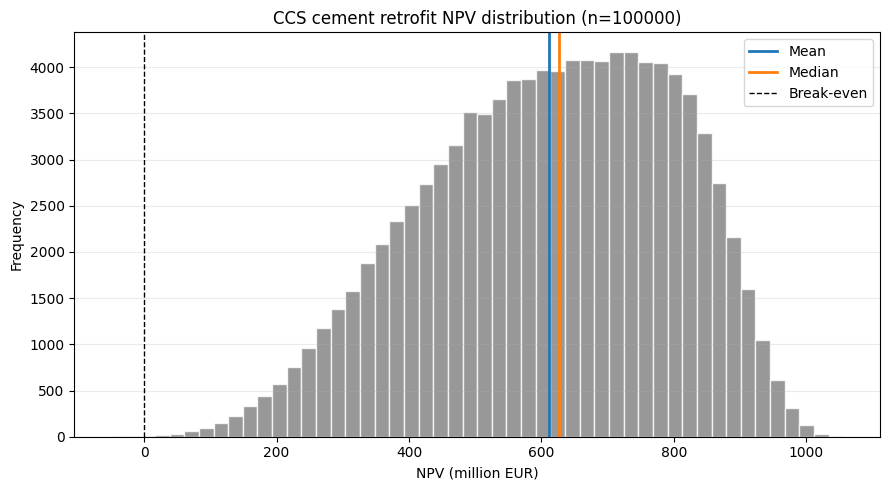

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(npv_million_eur, bins=50, color="tab:gray", edgecolor="white", alpha=0.8)
ax.axvline(npv_million_eur.mean(), color="tab:blue", linewidth=2, label="Mean")
ax.axvline(npv_million_eur.median(), color="tab:orange", linewidth=2, label="Median")
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"CCS cement retrofit NPV distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()


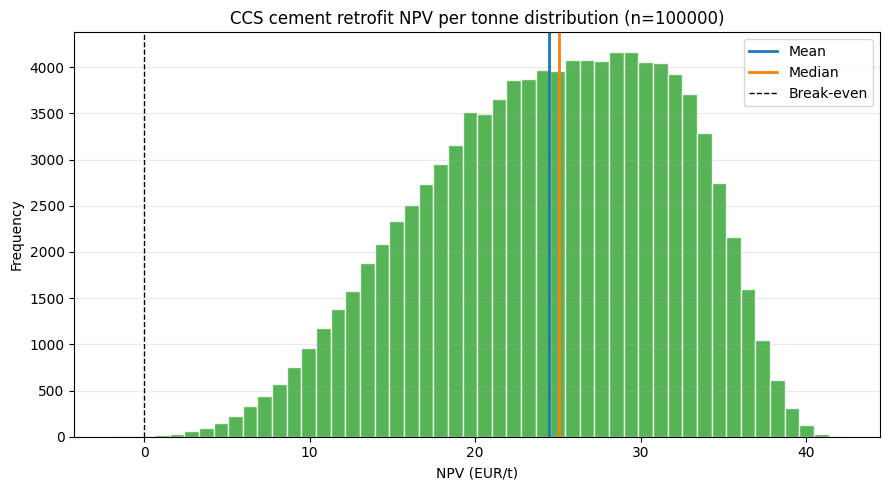

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    npv_eur_per_t,
    bins=50,
    color="tab:green",
    edgecolor="white",
    alpha=0.8,
)
ax.axvline(
    npv_eur_per_t.mean(),
    color="tab:blue",
    linewidth=2,
    label="Mean",
)
ax.axvline(
    npv_eur_per_t.median(),
    color="tab:orange",
    linewidth=2,
    label="Median",
)
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"CCS cement retrofit NPV per tonne distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (EUR/t)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()


In [6]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_electricity_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur",
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")


annual_revenue_eur             150.000000
annual_fixed_opex_eur           21.330796
annual_variable_opex_eur         6.664145
annual_fuel_cost_eur             2.821263
annual_electricity_cost_eur     31.087188
annual_emissions_cost_eur        4.555932
annual_net_cash_flow_eur        83.540675
Name: Mean annual value, million EUR, dtype: float64

In [7]:
retrofit_columns = [
    "capex_change_eur_per_t",
    "fixed_opex_change_eur_per_t",
    "variable_opex_change_eur_per_t",
    "fuel_consumption_reduction_fraction",
    "electricity_consumption_reduction_fraction",
    "emissions_reduction_fraction",
    "bau_capex_eur_per_t",
    "bau_fixed_opex_eur_per_t",
    "bau_variable_opex_eur_per_t",
    "bau_fuel_consumption_mwh_th_per_t",
    "bau_electricity_consumption_mwh_per_t",
    "bau_emissions_tco2_per_t",
]

available_retrofit_columns = [column for column in retrofit_columns if column in results]
retrofit_summary = results[available_retrofit_columns].describe(
    percentiles=[0.05, 0.5, 0.95]
)
retrofit_summary


,capex_change_eur_per_t,fixed_opex_change_eur_per_t,variable_opex_change_eur_per_t,fuel_consumption_reduction_fraction,electricity_consumption_reduction_fraction,emissions_reduction_fraction,bau_capex_eur_per_t,bau_fixed_opex_eur_per_t,bau_variable_opex_eur_per_t,bau_fuel_consumption_mwh_th_per_t,bau_electricity_consumption_mwh_per_t,bau_emissions_tco2_per_t
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,119.946835,6.998388,1.496923,0.651207,-0.951713,0.910090,160.012499,14.332408,5.167223,0.666500,0.086635,0.633377
std,37.542039,1.735444,0.865142,0.375716,0.951246,0.017345,5.770418,0.471200,0.235343,0.040049,0.004713,0.023522
min,55.000509,4.000200,0.000011,0.000024,-2.599937,0.880002,150.000263,13.009529,4.504187,0.610000,0.080000,0.600000
5%,61.526813,4.296030,0.150909,0.064576,-2.432559,0.882981,150.989862,13.451564,4.725440,0.614265,0.080499,0.602579
50%,119.803478,6.992326,1.494885,0.652239,-0.952996,0.910156,160.049191,14.411204,5.207742,0.659535,0.085806,0.629393
95%,178.520809,9.700315,2.845847,1.236444,0.530302,0.937031,169.007981,14.949464,5.474133,0.741932,0.095517,0.677623
max,184.999788,9.999998,2.999990,1.299998,0.700000,0.939999,169.999875,14.999998,5.499993,0.779352,0.099946,0.699866
